# 01 — preprocessing

**Feeds:** upstream of all single-cell panels

**Position in the chain:** run the numbered stages in order

Ported from the original analysis. Saved cell outputs are from the original run, and paths in them appear as `<analysis-root>/...`.

**Changes from the original notebook**, so that it runs from this repository:
1. Paths. The first code cell finds the repository from any working directory inside it; the original looked for `src/` at most two levels up. `PROJECT_ROOT`, which was the analysis directory, is now `$SCRNASEQ_INPUT_ROOT` (default `data/scrnaseq_inputs/`), where `00a_geo_trunk_morph.ipynb` and `00b_geo_human_embryo.ipynb` write this notebook's four inputs in the same layout. `DEV_ROOT`, under which the notebook writes, is `$SCRNASEQ_RESULTS_ROOT/trunk_main_dev/` (default `scrnaseq/output/trunk_main_dev/`) instead of the analysis directory's `trunk_main_dev/`.
2. Markdown only: the note above the data loading pointed to an archive notebook that is not in this repository; it now points to `00a` and `00b`.

No other line of code was changed.


# 01 - Preprocessing

Standalone stage: reads raw data and writes preprocessing intermediates.

In [ ]:
from pathlib import Path
import sys

for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "src" / "trunk_morph_ref").exists():
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate the repository root containing src/trunk_morph_ref/")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.trunk_morph_ref.paths import scrnaseq_input_root

# The GEO conversion outputs (00a, 00b), laid out as in the original analysis directory.
PROJECT_ROOT = scrnaseq_input_root(REPO_ROOT)

import os
os.chdir(REPO_ROOT)


Current dev checkpoint:

Sparse preprocessing with morph and embryo QC for SMD reruns

5.00: Subclustering of morph data all done. Compiling main figures.

4.03: Including CV > 1 cutoff in subclustering

4.02: Duplicate of 4.01, morph Leiden resolution 1.8

4.01: Duplicate of 4.00, morph Leiden resolution 1

4.00: Working from version 3.12, with CV cutoff but keeping variance normalization. Not focusing on alignment of embryo and morph data in later 3.2-3.5 versions. Starting work for initial submission figures.

3.12: Increasing minimum CV cutoff to 1. For reference, SOX2 CV is ~1.03 in morph data.

3.11: Including week 4 embryo data. It looks like some morph cell types may not be present in week 3 embyro data.

2.11: Imposing a minimum CV cutoff of 1/3 during preprocessing.

1.11: Early attempts at co-clustering required the removal of genes that were differentially expressed btwn entire morph and embryo datasets. These genes often had high expression levels, suggesting a minimum CV cutoff during pre-processing might be appropriate (but requiring re-runs of SMD). Alternatively, there was an apparent anti-correlation between SMD z-scores and mean expression levels, suggesting that high expression / low CV genes are less informative. We can perhaps try to get around this by just increasing z-score cutoff, at the risk of losing important genes. Also, it seems like given the very different range of z-scores between the two datasets, picking the top 100 genes may be more appropriate for comparison. I will try changing SMD gene cutoff to top 100 z-scores

1.10: First attempt at co-clustering w3 embryo and morph data using SMD genes. Multiple variables are renamed from 1.08 for clarity.

1.08: Performing pre-processing myself, setting 'normalize' to false in ray_SMD. Also scrambling order of genes to see if there is bias toward first gene in list in SMD

    - There is a bias, for small values of n_sub

1.07: Examining earlier human embryo scRNAseq dataset from Zeng et al Cell Stem Cell 2023. Clustering following Sam's manuscript methods


## Setup and Imports


In [ ]:
import matplotlib

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

In [ ]:
import pickle
import random

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy
import seaborn as sns
from cmcrameri.cm import batlow
from scipy.sparse import coo_matrix, csr_matrix, load_npz, save_npz

/opt/anaconda3/lib/python3.12/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/opt/anaconda3/lib/python3.12/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/opt/anaconda3/lib/python3.12/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/opt/anaconda3/lib/python3.12/site-packages/anndata/__init__.py:70: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  return module_get_attr_redirect(attr_name, deprecated_mapping=_DEPRECATED)
/opt/anaconda3/lib/python3.12/site-pa

In [ ]:
plt.rcParams["svg.fonttype"] = "none"  # Keep fonts editable in Illustrator

In [ ]:
from src.trunk_morph_ref.cell_ordering import ordered_cells_by_cluster_clustermap
from src.trunk_morph_ref.paths import init_output_paths, scrnaseq_results_root

# Outputs: $SCRNASEQ_RESULTS_ROOT (default scrnaseq/output/), under trunk_main_dev/ as in the original.
DEV_ROOT = scrnaseq_results_root(REPO_ROOT) / "trunk_main_dev"
RESULTS_DIR, MANUSCRIPT_FIG_DIR, EXTENDED_FIG_DIR = init_output_paths(DEV_ROOT)
from src.trunk_morph_ref.aggregation import cluster_averages_sparse_safe
from src.trunk_morph_ref.correlation import gene_corrcoef_sparse_safe
from src.trunk_morph_ref.plotting import (
    bold_selected_heatmap_yticklabels,
    hide_heatmap_axes_and_colorbar,
    keep_only_selected_heatmap_yticklabels,
    plot_empty_heatmap_axes,
)
from src.trunk_morph_ref.preprocessing import (
    assert_gene_id_index,
    contains_symbol,
    ensure_gene_id_index,
    filter_genes_sparse_safe as filter_genes,
    install_scanpy_symbol_defaults,
    normalize_unit_variance_sparse_safe as normalize_unit_variance,
    resolve_symbol_dict,
    resolve_symbols,
    symbols_missing,
    symbols_present,
    var_names_to_symbols,
)

# Use gene symbols for plot labels while keeping `var_names` as stable gene IDs.
install_scanpy_symbol_defaults(sc)


## Load Data
Read harmonized trunk morph and human embryo inputs used for downstream preprocessing.


Note: `00a_geo_trunk_morph.ipynb` and `00b_geo_human_embryo.ipynb` build this notebook's inputs from the
public GEO files, including the gene-name harmonization between the two datasets.


### Trunk Morph Data Loading


In [ ]:
# Read morph data
adata_morph_raw = sc.read_h5ad(PROJECT_ROOT / "sample_284.adata")

# Only analyze day 6 "No Bead" and "BMP4 Bead" morphs (cells with detected guides)
adata_morph_raw = adata_morph_raw[adata_morph_raw.obs.guide.isin(["HES7", "ETV4"])]
adata_morph_raw.obs["source"] = adata_morph_raw.obs["guide"].cat.rename_categories(
    {"ETV4": "No Bead Morph", "HES7": "BMP4 Bead Morph"}
)

# Print number of cells per morph sample
adata_morph_raw.obs.source.value_counts()

/var/folders/l_/r6wv9rf56fb1h8jjvhh7rl440000gp/T/ipykernel_67448/2459746478.py:6: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_morph_raw.obs["source"] = adata_morph_raw.obs["guide"].cat.rename_categories(


source
No Bead Morph      2893
BMP4 Bead Morph    2769
Name: count, dtype: int64

### Human Embryo Data Loading


In [ ]:
# Read human embryo data from the canonical raw input, with homogenized gene names matching morph data.
embryo_raw_path = (
    PROJECT_ROOT / "human_embryo" / "GSE155121" / "GSE155121_human_data_w3-4_genematch.h5ad"
)
if not embryo_raw_path.exists():
    raise FileNotFoundError(
        "Missing canonical embryo raw input: "
        + str(embryo_raw_path)
        + ". Dev stage 01 no longer falls back to top-level parity intermediates."
    )
adata_embryo_raw = sc.read_h5ad(embryo_raw_path)
with open(PROJECT_ROOT / "embryo_only_genes.pkl", "rb") as f:
    embryo_only_genes = pickle.load(f)
with open(PROJECT_ROOT / "morph_only_genes.pkl", "rb") as f:
    morph_only_genes = pickle.load(f)

# How many cells come from each embryo?
adata_embryo_raw.obs.value_counts("source")


In [ ]:
ensure_gene_id_index(adata_morph_raw)
ensure_gene_id_index(adata_embryo_raw)
assert_gene_id_index(adata_morph_raw)
assert_gene_id_index(adata_embryo_raw)

## Quality Control Metrics
Compute standard single-cell QC summaries before applying any stage filters.

### Trunk Morph QC Metrics
Plot read depth, detected genes, and mitochondrial fractions for the raw trunk morph cells.

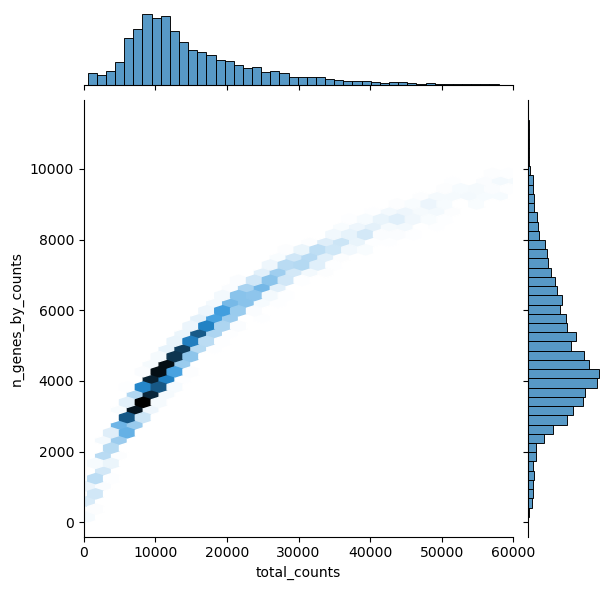

In [ ]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
morph_symbols = adata_morph_raw.var["gene_symbol"].astype(str)
adata_morph_raw.var["mt"] = morph_symbols.str.startswith("MT-")
# ribosomal genes
adata_morph_raw.var["ribo"] = morph_symbols.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata_morph_raw.var["hb"] = morph_symbols.str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(
    adata_morph_raw, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

# Plot number of reads vs number of detected genes for each cell
sns.jointplot(
    data=adata_morph_raw.obs,
    x="total_counts",
    y="n_genes_by_counts",
    kind="hex",
    xlim=[0, 60000],
)

<Axes: xlabel='pct_counts_mt', ylabel='Count'>

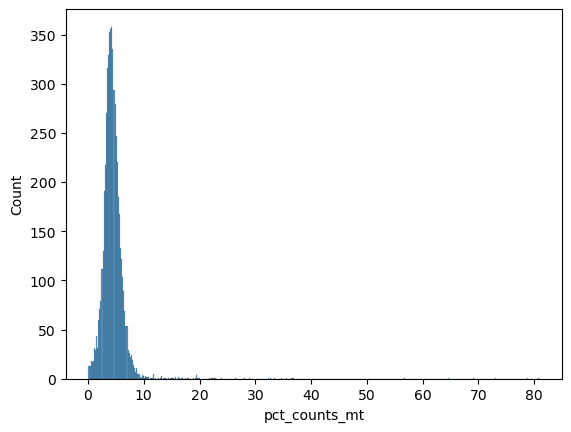

In [ ]:
# Histogram of % mito gene reads
sns.histplot(adata_morph_raw.obs["pct_counts_mt"])

### Human Embryo QC Metrics
Plot read depth, detected genes, and mitochondrial fractions for the raw embryo cells.

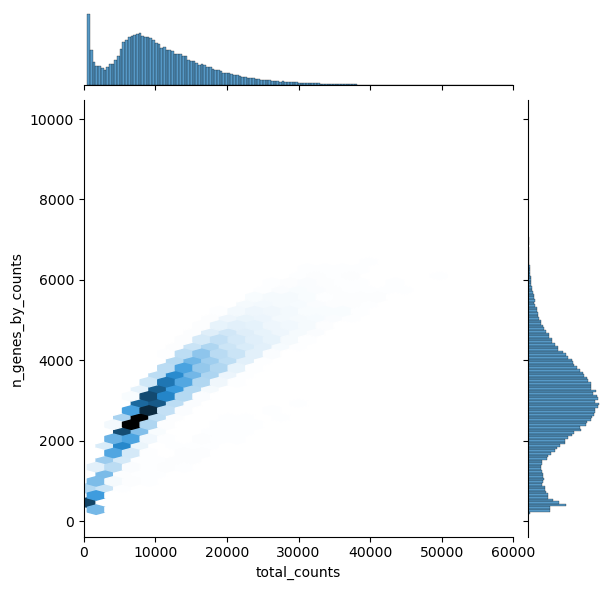

In [ ]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
embryo_symbols = adata_embryo_raw.var["gene_symbol"].astype(str)
adata_embryo_raw.var["mt"] = embryo_symbols.str.startswith("MT-")
# ribosomal genes
adata_embryo_raw.var["ribo"] = embryo_symbols.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata_embryo_raw.var["hb"] = embryo_symbols.str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(
    adata_embryo_raw, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

# Plot number of reads vs number of detected genes for each cell
sns.jointplot(
    data=adata_embryo_raw.obs,
    x="total_counts",
    y="n_genes_by_counts",
    kind="hex",
    xlim=[0, 60000],
)

<Axes: xlabel='pct_counts_mt', ylabel='Count'>

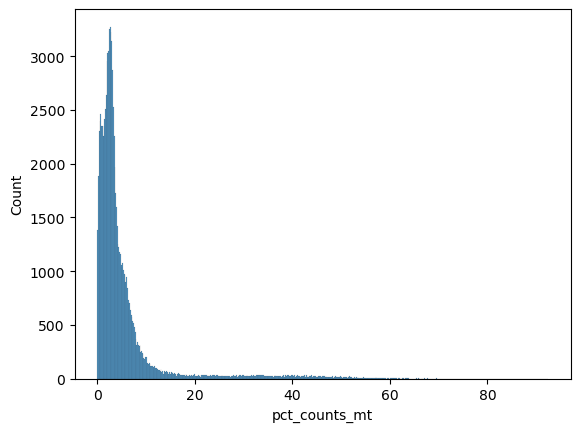

In [ ]:
# Histogram of % mito gene reads
sns.histplot(adata_embryo_raw.obs["pct_counts_mt"])

## Trunk Morph QC Filtering and Preprocessing
Apply the trunk morph QC thresholds, then build the filtered morph matrices used downstream.

In [ ]:
# Keep development outputs local to the experiment branch.
preprocess_stage_path = RESULTS_DIR / "intermediates" / "01_preprocessing"
preprocess_stage_path.mkdir(parents=True, exist_ok=True)

adata_morph = adata_morph_raw.copy()

# Trunk morph QC thresholds (Seurat-style metrics).
morph_qc_thresholds = {
    "total_counts_min": 5000,
    "n_genes_by_counts_min": 200,
    "n_genes_by_counts_max": 10000,
    "pct_counts_mt_max": 10.0,
}

morph_qc_audit = adata_morph.obs[
    ["source", "n_genes_by_counts", "total_counts", "pct_counts_mt"]
].copy()
morph_qc_audit["n_genes_by_counts"] = pd.to_numeric(
    morph_qc_audit["n_genes_by_counts"], errors="coerce"
)
morph_qc_audit["total_counts"] = pd.to_numeric(
    morph_qc_audit["total_counts"], errors="coerce"
)
morph_qc_audit["pct_counts_mt"] = pd.to_numeric(
    morph_qc_audit["pct_counts_mt"], errors="coerce"
)

morph_qc_audit["pass_total_counts"] = (
    morph_qc_audit["total_counts"] >= morph_qc_thresholds["total_counts_min"]
)
morph_qc_audit["pass_n_genes_by_counts"] = (
    morph_qc_audit["n_genes_by_counts"] >= morph_qc_thresholds["n_genes_by_counts_min"]
) & (
    morph_qc_audit["n_genes_by_counts"] <= morph_qc_thresholds["n_genes_by_counts_max"]
)
morph_qc_audit["pass_pct_counts_mt"] = (
    morph_qc_audit["pct_counts_mt"] <= morph_qc_thresholds["pct_counts_mt_max"]
)
morph_qc_audit["pass_qc"] = (
    morph_qc_audit["pass_total_counts"]
    & morph_qc_audit["pass_n_genes_by_counts"]
    & morph_qc_audit["pass_pct_counts_mt"]
)

print(
    f"{100 * morph_qc_audit['pass_qc'].mean():.2f}% of trunk morph cells remain after QC"
)
print(
    "Trunk morph QC failures (non-exclusive): "
    + f"low total_counts={int((~morph_qc_audit['pass_total_counts']).sum())}, "
    + f"out-of-range n_genes_by_counts={int((~morph_qc_audit['pass_n_genes_by_counts']).sum())}, "
    + f"high pct_counts_mt={int((~morph_qc_audit['pass_pct_counts_mt']).sum())}"
)

adata_morph = adata_morph[morph_qc_audit["pass_qc"].to_numpy()].copy()

# Downsample retained morph cells to the target read depth used for SMD input.
morph_minimum_reads = morph_qc_thresholds["total_counts_min"]
sc.pp.downsample_counts(
    adata_morph, counts_per_cell=morph_minimum_reads, replace=True, random_state=0
)
sc.pp.log1p(adata_morph)

print(
    f"{100 * len(adata_morph) / len(adata_morph_raw):.2f}% of cells remain after trunk morph QC"
)

# Build the morph matrix used for SMD input.
adata_morph_filtered = filter_genes(adata_morph, mean_cutoff=0.05, std_cutoff=0.05)
adata_morph_filtered = normalize_unit_variance(adata_morph_filtered)
counts = adata_morph_filtered.X
cv_mask = np.mean(counts, axis=0).transpose() < 1
adata_morph_filtered = adata_morph_filtered[:, cv_mask]

scipy.sparse.save_npz(preprocess_stage_path / "trunk_morph__smd_input.npz", adata_morph_filtered.X)
print(f"{len(adata_morph_filtered)} cells after pre-processing")
print(f"{adata_morph_filtered.shape[1]} genes after preprocessing")
print(f"Recommended n_sub ≈ {str(0.8 * len(adata_morph_filtered))[:4]}")

# Keep a non-SMD morph object with all non-constant genes for downstream steps.
adata_morph_nofilter = adata_morph.copy()
adata_morph = filter_genes(adata_morph, mean_cutoff=0, std_cutoff=0)
adata_morph = normalize_unit_variance(adata_morph)


## Stage Boundary Note
`01_preprocessing` now stops at QCed `.h5ad` stage outputs and `.npz` matrices ready for cluster SMD runs. Legacy morph z-score alignment is deferred to `02_trunk_main.ipynb`, so this notebook remains valid before any SMD z-scores exist.

## Human Embryo QC Filtering and Preprocessing
Apply embryo QC thresholds, then build the filtered embryo matrices used downstream.

In [ ]:
adata_embryo = adata_embryo_raw.copy()

# Apply the same QC metrics to embryo cells, keeping the historical 10k-read floor.
embryo_qc_thresholds = {
    "total_counts_min": 10000,
    "n_genes_by_counts_min": 200,
    "n_genes_by_counts_max": 10000,
    "pct_counts_mt_max": 10.0,
}

embryo_qc_audit = adata_embryo.obs[
    ["week_stage", "source", "n_genes_by_counts", "total_counts", "pct_counts_mt"]
].copy()
embryo_qc_audit["n_genes_by_counts"] = pd.to_numeric(
    embryo_qc_audit["n_genes_by_counts"], errors="coerce"
)
embryo_qc_audit["total_counts"] = pd.to_numeric(
    embryo_qc_audit["total_counts"], errors="coerce"
)
embryo_qc_audit["pct_counts_mt"] = pd.to_numeric(
    embryo_qc_audit["pct_counts_mt"], errors="coerce"
)

embryo_qc_audit["pass_total_counts"] = (
    embryo_qc_audit["total_counts"] >= embryo_qc_thresholds["total_counts_min"]
)
embryo_qc_audit["pass_n_genes_by_counts"] = (
    embryo_qc_audit["n_genes_by_counts"] >= embryo_qc_thresholds["n_genes_by_counts_min"]
) & (
    embryo_qc_audit["n_genes_by_counts"] <= embryo_qc_thresholds["n_genes_by_counts_max"]
)
embryo_qc_audit["pass_pct_counts_mt"] = (
    embryo_qc_audit["pct_counts_mt"] <= embryo_qc_thresholds["pct_counts_mt_max"]
)
embryo_qc_audit["pass_qc"] = (
    embryo_qc_audit["pass_total_counts"]
    & embryo_qc_audit["pass_n_genes_by_counts"]
    & embryo_qc_audit["pass_pct_counts_mt"]
)

print(
    f"{100 * embryo_qc_audit['pass_qc'].mean():.2f}% of embryo cells remain after QC"
)
print(
    "Embryo QC failures (non-exclusive): "
    + f"low total_counts={int((~embryo_qc_audit['pass_total_counts']).sum())}, "
    + f"out-of-range n_genes_by_counts={int((~embryo_qc_audit['pass_n_genes_by_counts']).sum())}, "
    + f"high pct_counts_mt={int((~embryo_qc_audit['pass_pct_counts_mt']).sum())}"
)

adata_embryo = adata_embryo[embryo_qc_audit["pass_qc"].to_numpy()].copy()

embryo_minimum_reads = embryo_qc_thresholds["total_counts_min"]
sc.pp.downsample_counts(
    adata_embryo, counts_per_cell=embryo_minimum_reads, replace=True, random_state=0
)
sc.pp.log1p(adata_embryo)

print(
    f"{100 * len(adata_embryo) / len(adata_embryo_raw):.2f}% of cells remain after embryo QC"
)

# Build the embryo matrix used for SMD input.
adata_embryo_filtered = filter_genes(adata_embryo, mean_cutoff=0.05, std_cutoff=0.05)
adata_embryo_filtered = normalize_unit_variance(adata_embryo_filtered)
counts = adata_embryo_filtered.X
cv_mask = np.mean(counts, axis=0).transpose() < 1
adata_embryo_filtered = adata_embryo_filtered[:, cv_mask]

scipy.sparse.save_npz(preprocess_stage_path / "human_embryo_w3w4__smd_input.npz", adata_embryo_filtered.X)
print(f"{len(adata_embryo_filtered)} cells after pre-processing")
print(f"{adata_embryo_filtered.shape[1]} genes after preprocessing")
print(f"Recommended n_sub ≈ {str(0.8 * len(adata_embryo_filtered))[:5]}")

# Optional: preserve the scrambled gene-order test hook used for SMD diagnostics.
gene_order = list(range(len(adata_embryo_filtered.var)))
random.Random(0).shuffle(gene_order)
# adata_shuffle = adata_embryo_filtered[:, gene_order]
# scipy.sparse.save_npz("embryo-w3_scrambled_1.10.npz", adata_shuffle.X)

# Keep a non-SMD embryo object with all non-constant genes for downstream steps.
adata_embryo_nofilter = adata_embryo.copy()
adata_embryo = filter_genes(adata_embryo, mean_cutoff=0, std_cutoff=0)
adata_embryo = normalize_unit_variance(adata_embryo)

for _adata in [
    adata_morph_raw,
    adata_embryo_raw,
    adata_morph,
    adata_morph_filtered,
    adata_morph_nofilter,
    adata_embryo,
    adata_embryo_filtered,
    adata_embryo_nofilter,
]:
    assert_gene_id_index(_adata)


## Save Stage Outputs
Persist preprocessing intermediates for downstream notebooks and record stage metadata.


In [ ]:
from src.trunk_morph_ref.pipeline_io import (
    load_h5ad,
    load_npy,
    load_pickle,
    save_h5ad,
    save_json,
    save_npy,
    save_pickle,
    stage_dir,
)

In [ ]:
stage_path = stage_dir(RESULTS_DIR, "01_preprocessing")
save_h5ad(adata_morph_raw, stage_path / "adata_morph_raw.h5ad")
save_h5ad(adata_embryo_raw, stage_path / "adata_embryo_raw.h5ad")
save_h5ad(adata_morph, stage_path / "adata_morph.h5ad")
save_h5ad(adata_morph_filtered, stage_path / "adata_morph_filtered.h5ad")
save_h5ad(adata_morph_nofilter, stage_path / "adata_morph_nofilter.h5ad")
save_h5ad(adata_embryo, stage_path / "adata_embryo.h5ad")
save_h5ad(adata_embryo_filtered, stage_path / "adata_embryo_filtered.h5ad")
save_h5ad(adata_embryo_nofilter, stage_path / "adata_embryo_nofilter.h5ad")
save_pickle(embryo_only_genes, stage_path / "embryo_only_genes.pkl")
save_pickle(morph_only_genes, stage_path / "morph_only_genes.pkl")
save_npy(gene_order, stage_path / "gene_order.npy")

# Persist cell-level QC audits for transparency and reviewer-response analyses.
morph_qc_audit.to_csv(stage_path / "morph_cell_qc_audit.csv")
save_json(morph_qc_thresholds, stage_path / "morph_qc_thresholds.json")
embryo_qc_audit.to_csv(stage_path / "embryo_cell_qc_audit.csv")
save_json(embryo_qc_thresholds, stage_path / "embryo_qc_thresholds.json")


save_json(
    {
        "stage": "01_preprocessing",
        "seed_policy": "all seeds set to 0",
        "smd_input_files": {
            "morph": "trunk_morph__smd_input.npz",
            "embryo": "human_embryo_w3w4__smd_input.npz"
        },
        "morph_qc": morph_qc_thresholds,
        "embryo_qc": embryo_qc_thresholds,
        "morph_cells_retained_after_qc": int(morph_qc_audit["pass_qc"].sum()),
        "morph_cells_total_raw": int(len(morph_qc_audit)),
        "embryo_cells_retained_after_qc": int(embryo_qc_audit["pass_qc"].sum()),
        "embryo_cells_total_raw": int(len(embryo_qc_audit)),
    },
    stage_path / "meta.json",
)
print(f"Saved preprocessing intermediates to {stage_path}")
